In [1]:
from scipy.signal import savgol_filter
from RamanModel import *
from HelperFunctions import *
import numpy as np
import matplotlib.pyplot as plt

# Create an example spectrum

We create a single example of a spectrum

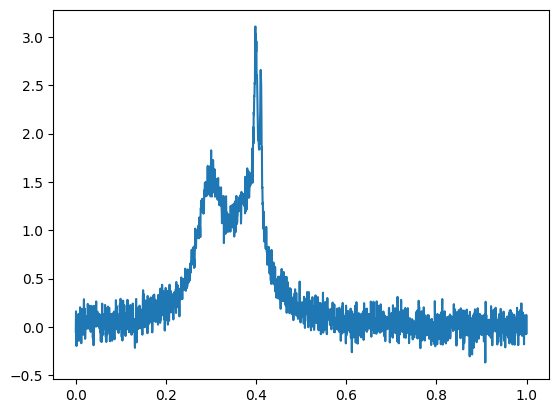

In [63]:
parameters = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.1, 1),
    "gamma_range": (0.001, 0.05),
    "x_min": 0,
    "x_max": 1
}

x = np.linspace(0, 1, 1876)
x, y, params = generateCurve(parameters, 4, len(x), noise_sigma=0.1)
plt.plot(x, y)

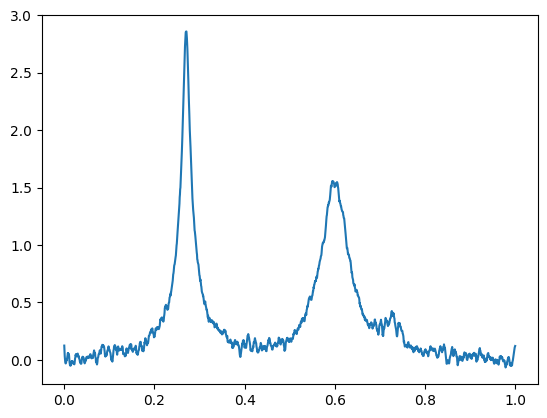

In [3]:
filtered = savgol_filter(y, window_length=21, polyorder=3)
plt.plot(x, filtered)


Generated Curve Parameters:
-------------------------------------------------------
Peak ID    | Center       | Amplitude    | Gamma       
-------------------------------------------------------
0          | 0.2710       | 0.4566       | 0.0344      
1          | 0.6002       | 0.7639       | 0.0367      
2          | 0.7269       | 0.1143       | 0.0194      
3          | 0.2702       | 0.9550       | 0.0095      
-------------------------------------------------------



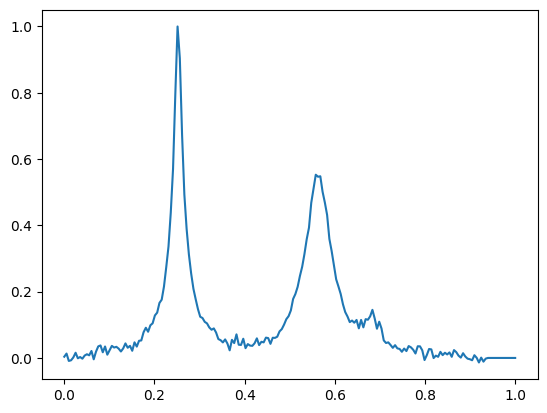

In [4]:
test = downsample_and_normalize(filtered, 200)
flattened_x = np.linspace(0, 1, 200)
plt.plot(flattened_x, test)
print_peak_params(params)

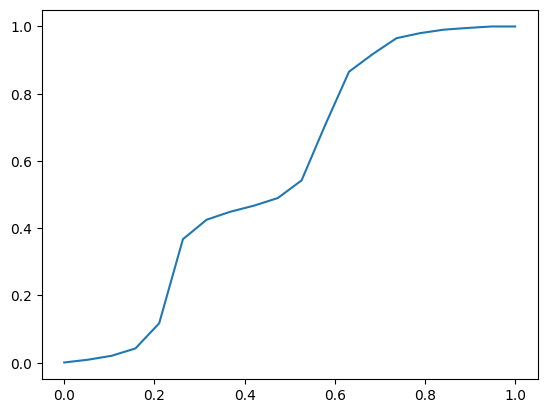

In [5]:
test2 = create_probability_map(y, num_peaks=4, resolution=20)
plt.plot(np.linspace(0,1,20), test2)

# Shifting Axes

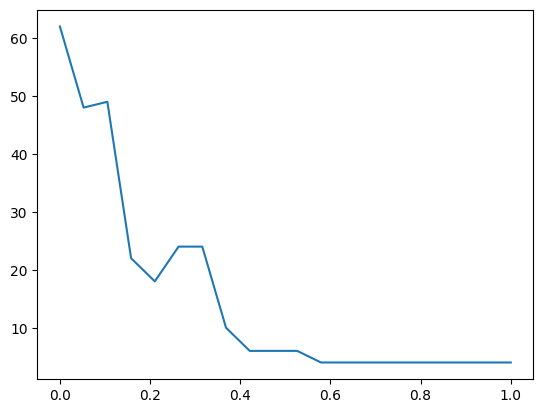

In [6]:
shifted = shift_axis(filtered,20)
plot_x = np.linspace(0,1,20)
plt.plot(plot_x, shifted)

# Run Simulated Annealing

Running simulated annealing to generate heatmap

In [57]:
def simulated_annealingV2(spectrum, length, kmax, max_temp, cooling_factor, samples, num_repetitions):
    """
    Creates a map of likely peak positions by recording posisitons and temperatures. This can be later
    flattened to produce a probability map. This function is likely deprecated in favor of less computationally
    expensive approaches.
    """

    map = []

    best_state = None
    best_energy = -np.inf
    cool = cooling_factor ** (1 / kmax)

    for i in range(num_repetitions):

        s_current = np.random.randint(0, length-1)
        energy_current = spectrum[s_current]
        T = max_temp

        for j in range(kmax):
            #T = T/((cooling_factor)**(1/kmax))
            indices = np.random.randint(0, length - 1, samples)
            uniforms = np.random.random(samples)

            T /= cool
            invT = 1.0 / max(T, 1e-12)
            
            for k in range(samples):
                #s_new = np.random.randint(0, length-1)
                s_new = indices[k]
                u = uniforms[k]
                
                energy_new = spectrum[s_new]
                diff = energy_new - energy_current
                
                if diff > 0 or u < np.exp(diff * invT):
                    s_current = s_new
                    energy_current = energy_new

                    if energy_current > best_energy:
                        best_energy = energy_current
                        best_state = s_current

            map.append((T, s_current))
    #print(f'Number of samples generated: {len(map)}')
    
    return best_energy, best_state, map

In [61]:
import cProfile
import pstats

profiler = cProfile.Profile()
profiler.enable()

energy, index, map = simulated_annealingV2(y, length=len(y), kmax=100, max_temp=0.5, cooling_factor=400, samples=100, num_repetitions=400)

profiler.disable()

stats = pstats.Stats(profiler)
stats.sort_stats("cumtime")
stats.print_stats(20)

         320119 function calls (320118 primitive calls) in 5.303 seconds

   Ordered by: cumulative time
   List reduced from 56 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    5.297    2.648 {built-in method builtins.exec}
        1    0.002    0.002    5.297    5.297 C:\Users\Saulo\AppData\Local\Temp\ipykernel_3108\1742521220.py:1(<module>)
        1    4.862    4.862    5.295    5.295 C:\Users\Saulo\AppData\Local\Temp\ipykernel_3108\2039746619.py:1(simulated_annealingV2)
    40000    0.057    0.000    0.403    0.000 E:\Root\Faculdade\Raman Fitting Pipeline\Raman-Fitting-Pipeline\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3287(prod)
    40000    0.113    0.000    0.346    0.000 E:\Root\Faculdade\Raman Fitting Pipeline\Raman-Fitting-Pipeline\venv\Lib\site-packages\numpy\_core\fromnumeric.py:66(_wrapreduction)
    40000    0.170    0.000    0.170    0.000 {method 'reduce' of 'numpy.ufunc' objec

In [60]:
import timeit

t = timeit.repeat(
    lambda: simulated_annealingV2(
        y,
        len(y),
        100,
        0.5,
        400,
        100,
        400
    ),
    repeat=5,
    number=1
)

print(t)
print("Best:", min(t))
print("Average:", sum(t)/len(t))

[4.601046099793166, 4.569232499692589, 4.595277800224721, 4.608049599919468, 4.590379599947482]
Best: 4.569232499692589
Average: 4.592797119915486


In [59]:
import time

start_wall = time.perf_counter()
start_cpu = time.process_time()

energy, index, map = simulated_annealingV2(y, length=len(y), kmax=100, max_temp=0.5, cooling_factor=400, samples=100, num_repetitions=400)

end_cpu = time.process_time()
end_wall = time.perf_counter()

print("Wall:", end_wall - start_wall)
print("CPU :", end_cpu - start_cpu)

Wall: 4.591162399854511
CPU : 4.59375


In [62]:
flattened = flatten_SA_map(map, len(y), samples_per_pixel=20, function=log_transform)
#flattened = flatten_SA_map(map, len(y), samples_per_pixel=35)

IndexError: index 93 is out of bounds for axis 0 with size 93

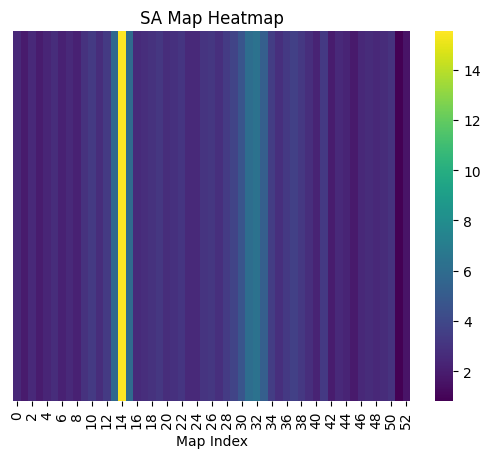

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(flattened.reshape(1, -1), cmap="viridis", cbar=True)

plt.title("SA Map Heatmap")
plt.xlabel("Map Index")
plt.yticks([])

plt.show()

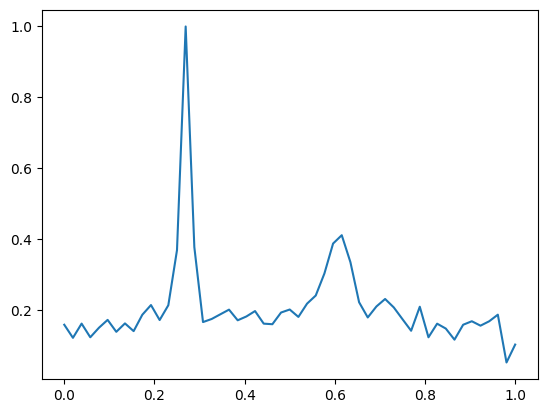

In [24]:
flattened_x = np.linspace(0, 1, (len(y)//35))
plt.plot(flattened_x, (flattened/max(flattened)))


In [13]:
# TODO: Test adding weight related to the temperature to makes these differences even more significant.

In [14]:
test = np.zeros(len(y)//20)
accum = 0
idx = 0
for i in range(1, len(y)+1):
    accum += y[i-1]
    if (i%20 == 0):
        test[idx] = accum/20
        accum = 0
        idx += 1 